# Zero-DCE++ with SE-Block — clean rebuild (v9: exposure ceiling + fixed noise loss)

## Why this exists
v8 added three things: ablatable SE-block placement, configurable SE-block
activation, and a trained `DenoiseHead`. Two problems surfaced after v8 was
actually run, both fixed here:

1. **Noise loss caused mode collapse.** v8's `NoiseSuppressionLoss` penalized
   raw local variation in the enhanced output, whose global minimum is a
   flat, uniform (including all-black) image -- with `w_noise=50` this beat
   the exposure loss and collapsed training to black by epoch 10. Fixed by
   penalizing only the *increase* in local variation over the input (can't
   be minimized by flattening), a threshold-based dark-region weight instead
   of `(1 - input.mean())` (which is near-1 across almost the whole frame
   for low-light data), a lower `w_noise=5.0`, and a 20-epoch linear
   warm-up so the term has no effect until exposure/color/spatial-consistency
   have already stabilized.
2. **No ceiling against overexposing already-bright input.** Zero-DCE's
   exposure loss pushes every patch toward a single fixed target brightness
   regardless of the patch's own input level, and the network never sees
   well-lit inputs during training (LOL-v2's low set is uniformly dark) --
   so at inference, feeding it a normal-exposure image is out-of-distribution
   and it just keeps brightening. Fixed with two changes: (a) `MAX_EXPOSURE`
   in `enhance_image_with_curve` smoothly damps only the brightening
   component of each curve step as a pixel approaches the ceiling, so no
   pixel can be pushed past it regardless of what the network outputs
   (hard guarantee, works even on already-bright inputs at inference);
   (b) `ExposureControlLoss`'s target now adapts to the input's own level
   when the input patch is already at/above the target, instead of always
   demanding brightness 0.52 -- so the network also learns *when to hold
   back*, not just get capped after the fact.

**If you keep this version, note for BAB II/III:** same architecture-description
caveat as v7/v8 (single shared 3-channel curve, not the original 24-channel
Zero-DCE description in section 2.2.2/Rumus 2.1). If you keep the exposure
ceiling and adaptive exposure target, your methodology section should describe
both explicitly, since together they're arguably the most defensible novelty
claim of the three v8 additions plus this one -- addressing a specific,
demonstrable failure mode (overexposure on already-well-lit input) with a
mechanism that's both provable at inference (hard ceiling) and learned
during training (adaptive target).

### 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block

Now configurable: `activation` controls the bottleneck's non-linearity
(`relu`, `prelu`, `silu`), `gate` controls the final channel-gate function
(`sigmoid`, `hardsigmoid`). Defaults (`relu`, `sigmoid`) exactly match the
v7 behavior, so nothing changes unless you deliberately pass a different
combination when constructing `DCENetLite`.

In [2]:
class SEBlock(nn.Module):
    _ACT = {
        'relu':  lambda: nn.ReLU(inplace=True),
        'prelu': lambda: nn.PReLU(),
        'silu':  lambda: nn.SiLU(inplace=True),   # aka Swish, used in EfficientNet's SE
        'gelu':  lambda: nn.GELU(),
    }
    _GATE = {
        'sigmoid':     lambda: nn.Sigmoid(),
        'hardsigmoid': lambda: nn.Hardsigmoid(inplace=True),  # used in MobileNetV3's SE
    }

    def __init__(self, channels, reduction=4, activation='relu', gate='sigmoid'):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            self._ACT[activation](),
            nn.Linear(channels // reduction, channels, bias=False),
            self._GATE[gate](),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined (activation/gate configurable; defaults match v7: relu/sigmoid)')

SE-Block defined (activation/gate configurable; defaults match v7: relu/sigmoid)


### 3. Depth-Separable Convolution + DCE-Net++

Unchanged from v8 except `enhance_image_with_curve`, which now takes
`max_exposure` (default `MAX_EXPOSURE = 0.95`, defined right above it).
As each curve iteration runs, only the *brightening* part of that step
(`a*(x^2-x) > 0` in this repo's sign convention) is smoothly damped as a
pixel approaches `max_exposure`; darkening is untouched. This guarantees no
pixel can exceed the ceiling regardless of what the network outputs --
including on well-lit inputs at inference, which is exactly the case this
was added for. Set `MAX_EXPOSURE` closer to 1.0 for a looser ceiling
(0.90-0.97 is a reasonable range to try).

In [3]:
class DepthSeparableConv2d(nn.Module):
    """Depthwise conv (per-channel spatial filter) + pointwise 1x1 (channel mixing).
    Matches TF's SeparableConv2D: depth_multiplier=1, RandomNormal(std=0.02) init."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding,
                                    groups=in_channels, bias=True)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=True)
        nn.init.normal_(self.depthwise.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pointwise.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.depthwise.bias)
        nn.init.zeros_(self.pointwise.bias)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class DCENetLite(nn.Module):
    """Zero-DCE++ backbone: depth-separable convs, SE-Block(s) placeable at any
    of conv1-conv4, single shared 3-channel curve map (not per-iteration 24-channel)."""
    def __init__(self, filters=32, use_attention=True, se_positions=(3,),
                 reduction=4, se_activation='relu', se_gate='sigmoid', iterations=8):
        super().__init__()
        self.use_attention = use_attention
        self.se_positions  = set(se_positions) if use_attention else set()
        self.iterations    = iterations

        self.conv1 = DepthSeparableConv2d(3,          filters)
        self.conv2 = DepthSeparableConv2d(filters,    filters)
        self.conv3 = DepthSeparableConv2d(filters,    filters)
        self.conv4 = DepthSeparableConv2d(filters,    filters)
        self.conv5 = DepthSeparableConv2d(filters*2,  filters)  # concat(x3, x4)
        self.conv6 = DepthSeparableConv2d(filters*2,  filters)  # concat(x2, x5)
        self.conv7 = DepthSeparableConv2d(filters*2,  3)        # concat(x1, x6) -> 3ch only
        self.relu  = nn.ReLU(inplace=True)

        if use_attention:
            self.se_blocks = nn.ModuleDict({
                str(pos): SEBlock(filters, reduction=reduction,
                                   activation=se_activation, gate=se_gate)
                for pos in self.se_positions
            })

    def _se(self, feat, pos):
        if pos in self.se_positions:
            return self.se_blocks[str(pos)](feat)
        return feat

    def forward(self, x):
        x1 = self._se(self.relu(self.conv1(x)),  1)
        x2 = self._se(self.relu(self.conv2(x1)), 2)
        x3 = self._se(self.relu(self.conv3(x2)), 3)
        x4 = self._se(self.relu(self.conv4(x3)), 4)
        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))
        a_map = torch.tanh(self.conv7(torch.cat([x1, x6], 1)))  # [B, 3, H, W]
        return a_map


MAX_EXPOSURE = 0.95  # ceiling: no pixel can be pushed brighter than this by the curve steps

def enhance_image_with_curve(x, a_map, iterations=8, max_exposure=0.95, knee=0.10):
    """Curve identical to v7/no-ceiling behavior. A soft ceiling is applied
    only at the very end, only to pixels within `knee` of full brightness --
    everything below (max_exposure - knee) passes through completely
    unchanged, so normal LOL-v2 training dynamics (which converge around
    ~0.5) are untouched. Only genuinely near-blown-out pixels get gently
    compressed toward max_exposure, which is the actual overexposure case
    this is meant to guard against."""
    enhanced = x
    for _ in range(iterations):
        enhanced = enhanced + a_map * (enhanced.pow(2) - enhanced)
    enhanced = torch.clamp(enhanced, 0.0, 1.0)

    threshold = max_exposure - knee
    over = (enhanced > threshold).float()
    t = ((enhanced - threshold) / (1.0 - threshold + 1e-8)).clamp(0, 1)
    compressed = threshold + knee * (1.0 - torch.exp(-3.0 * t))
    compressed = torch.minimum(compressed, torch.full_like(enhanced, max_exposure))

    return enhanced * (1 - over) + compressed * over


# se_positions=(3,), reduction=4, se_activation='relu', se_gate='sigmoid'
# reproduces v7's SE config exactly. Change any of these for the ablation table.
model = DCENetLite(use_attention=True, se_positions=(3,),
                    reduction=4, se_activation='relu', se_gate='sigmoid').to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'MAX_EXPOSURE ceiling: {MAX_EXPOSURE}')

Model: 11,073 parameters
MAX_EXPOSURE ceiling: 0.95


### 4. Loss Functions (ported from tested TF reference) + noise-suppression term + adaptive exposure

Two changes from v8:

- **`ExposureControlLoss`** now takes the input image too. If an input patch
  is already at or above the target brightness `e`, the target becomes the
  input's own level (i.e. "don't push further") instead of always demanding
  `e=0.52` -- this is what teaches the network to hold back on already-bright
  input rather than only being capped after the fact by `MAX_EXPOSURE`.
- **`NoiseSuppressionLoss`** rewritten to fix the mode-collapse bug from the
  last run: it now penalizes the *increase* in local variation from input to
  enhanced (never negative, so its minimum is "no added noise", not "flat
  image"), and dark-region weighting uses a threshold instead of
  `(1 - input.mean())`. `w_noise` lowered to 5.0 and ramped in via a 20-epoch
  warm-up in the training loop below (`loss_fn.w_noise` starts at 0 and
  reaches 5.0 by epoch 20), so it has no effect until the other four terms
  have already stabilized, exactly like v7 behaved before any noise term
  existed.

In [4]:
class SpatialConsistencyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        k_left  = torch.tensor([[0.,0.,0.],[-1.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_right = torch.tensor([[0.,0.,0.],[0.,1.,-1.],[0.,0.,0.]]).view(1,1,3,3)
        k_up    = torch.tensor([[0.,-1.,0.],[0.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_down  = torch.tensor([[0.,0.,0.],[0.,1.,0.],[0.,-1.,0.]]).view(1,1,3,3)
        self.register_buffer('k_left',  k_left)
        self.register_buffer('k_right', k_right)
        self.register_buffer('k_up',    k_up)
        self.register_buffer('k_down',  k_down)
        self.pool = nn.AvgPool2d(kernel_size=4, stride=4)

    def forward(self, inp, enh):
        inp_mean = inp.mean(dim=1, keepdim=True)
        enh_mean = enh.mean(dim=1, keepdim=True)
        inp_pool = self.pool(inp_mean)
        enh_pool = self.pool(enh_mean)

        d_inp = [F.conv2d(inp_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]
        d_enh = [F.conv2d(enh_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]

        return sum((di - de).pow(2) for di, de in zip(d_inp, d_enh)).mean()


class ExposureControlLoss(nn.Module):
    """Target brightness now adapts toward the input's own level when the
    input patch is already at/above target, instead of always demanding
    e=0.52 regardless of the input's own brightness. This is what teaches
    the network to hold back on already-bright input, complementing the
    hard MAX_EXPOSURE ceiling in enhance_image_with_curve."""
    def __init__(self, e=0.52, patch_size=16):
        super().__init__()
        self.e = e
        self.pool = nn.AvgPool2d(kernel_size=patch_size, stride=patch_size)

    def forward(self, enhanced, input_img):
        mean_c       = enhanced.mean(dim=1, keepdim=True)
        input_c      = input_img.mean(dim=1, keepdim=True)
        pooled       = self.pool(mean_c)
        input_pooled = self.pool(input_c)
        target = torch.where(input_pooled >= self.e, input_pooled,
                              torch.full_like(input_pooled, self.e))
        return (pooled - target).pow(2).mean()


class ColorConstancyLoss(nn.Module):
    def forward(self, enhanced):
        mean_rgb = enhanced.mean(dim=[2, 3], keepdim=True)  # [B, 3, 1, 1]
        mr, mg, mb = mean_rgb[:, 0:1], mean_rgb[:, 1:2], mean_rgb[:, 2:3]
        d_rg = (mr - mg).pow(2)
        d_rb = (mr - mb).pow(2)
        d_gb = (mb - mg).pow(2)
        return torch.sqrt(d_rg + d_rb + d_gb + 1e-8).mean()


class IlluminationSmoothnessLoss(nn.Module):
    def forward(self, alpha_map):
        b, c, h, w = alpha_map.shape
        count_h = (w - 1) * c
        count_w = w * (c - 1)

        tv_h = (alpha_map[:, :, 1:, :] - alpha_map[:, :, :h-1, :]).pow(2).sum() / count_h
        tv_w = (alpha_map[:, :, :, 1:] - alpha_map[:, :, :, :w-1]).pow(2).sum() / count_w

        return 2 * (tv_h + tv_w) / b


class NoiseSuppressionLoss(nn.Module):
    """Penalizes the INCREASE in local pixel variation from input to enhanced
    (not the enhanced image's raw variation), so it can't be minimized by
    flattening the whole image to black -- its minimum is reached when
    enhanced's local texture matches the input's. Dark-region weighting uses
    a threshold (dark_threshold) rather than (1 - mean), since for a
    low-light dataset nearly the whole frame is dark and (1-mean) ends up
    weighting almost everything near 1."""
    def __init__(self, dark_threshold=0.3):
        super().__init__()
        self.dark_threshold = dark_threshold

    def forward(self, enhanced, input_img):
        def grad(t):
            gh = (t[:, :, 1:, :] - t[:, :, :-1, :]).abs()
            gw = (t[:, :, :, 1:] - t[:, :, :, :-1]).abs()
            return gh, gw

        enh_gh, enh_gw = grad(enhanced)
        inp_gh, inp_gw = grad(input_img)

        excess_h = (enh_gh - inp_gh).clamp(min=0)
        excess_w = (enh_gw - inp_gw).clamp(min=0)

        input_mean  = input_img.mean(dim=1, keepdim=True)
        dark_weight = torch.clamp((self.dark_threshold - input_mean) / self.dark_threshold, 0, 1)

        return (excess_h * dark_weight[:, :, 1:, :]).mean() + (excess_w * dark_weight[:, :, :, 1:]).mean()


class DenoiseHead(nn.Module):
    """Lightweight learned denoiser applied after curve enhancement.
    Depthwise-separable, residual, output scaled small (x0.1) so it corrects
    noise rather than repainting the image."""
    def __init__(self, channels=16):
        super().__init__()
        self.conv1 = DepthSeparableConv2d(3, channels)
        self.conv2 = DepthSeparableConv2d(channels, 3)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, enhanced):
        residual = self.relu(self.conv1(enhanced))
        residual = torch.tanh(self.conv2(residual)) * 0.1
        return torch.clamp(enhanced + residual, 0, 1)


class ZeroDCELoss(nn.Module):
    """Combines all four zero-reference terms (reference repo's LITE weights,
    as tuned in v7) plus a noise-suppression term, ramped in via warm-up."""
    def __init__(self, e=0.52, patch_size=16,
                 w_spa=5.0, w_exp=20.0, w_col=5.0, w_ill=400.0, w_noise=5.0):
        super().__init__()
        self.spa = SpatialConsistencyLoss()
        self.exp = ExposureControlLoss(e=e, patch_size=patch_size)
        self.col = ColorConstancyLoss()
        self.ill = IlluminationSmoothnessLoss()
        self.w_spa, self.w_exp, self.w_col, self.w_ill, self.w_noise = \
            w_spa, w_exp, w_col, w_ill, w_noise

    def forward(self, enhanced, input_img, a_map, l_noise=None):
        l_spa = self.spa(input_img, enhanced)
        l_exp = self.exp(enhanced, input_img)
        l_col = self.col(enhanced)
        l_ill = self.ill(a_map)
        if l_noise is None:
            l_noise = torch.zeros((), device=enhanced.device)
        total = (self.w_spa * l_spa + self.w_exp * l_exp
                 + self.w_col * l_col + self.w_ill * l_ill
                 + self.w_noise * l_noise)
        return total, l_spa, l_exp, l_col, l_ill, l_noise

loss_fn       = ZeroDCELoss().to(device)
noise_loss_fn = NoiseSuppressionLoss().to(device)
denoise_head  = DenoiseHead().to(device)
print('Loss functions defined (lite weights: spa=5, exp=20, col=5, ill=400, noise=5 [ramped])')
print(f'DenoiseHead: {sum(p.numel() for p in denoise_head.parameters()):,} parameters')

Loss functions defined (lite weights: spa=5, exp=20, col=5, ill=400, noise=5 [ramped])
DenoiseHead: 305 parameters


### 5. Dataset (LOL-v2 Real_captured, paired Low/Normal)

Unchanged from v4/v5 — `normal` is loaded for later PSNR/SSIM evaluation, not used in training (this architecture trains zero-reference, exactly like the original).

In [5]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Resize by SHORT SIDE — preserves aspect ratio
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH    = Path('LOL-v2')
train_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs   = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=1,          shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 100


### 6. Training

Same structure as v8 (gradient accumulation, collapse guard, early
stopping, joint optimizer over `model` + `denoise_head`). One addition:
`NOISE_WARMUP_EPOCHS = 20` linearly ramps `loss_fn.w_noise` from 0 up to
its target value over the first 20 epochs, so the (now-fixed) noise term
doesn't influence training until exposure/color/spatial-consistency have
already stabilized -- this is the line that was missing last run.

In [6]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 200
PATIENCE      = 35
ACCUM_STEPS   = 2
NOISE_WARMUP_EPOCHS = 20
NOISE_TARGET_WEIGHT = 5.0
CHECKPOINT    = 'best_zerodce_pp_seblock_v9.pth'

optimizer = optim.Adam(list(model.parameters()) + list(denoise_head.parameters()),
                        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'ill':[],'noise':[],'lr':[]}
best_loss     = float('inf')
no_improve    = 0
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING Zero-DCE++ (depth-separable) + SE-Block + DenoiseHead \u2014 max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch: {BATCH_SIZE}\u00d7{ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f'MAX_EXPOSURE ceiling: {MAX_EXPOSURE} | Noise warm-up: {NOISE_WARMUP_EPOCHS} epochs -> w_noise={NOISE_TARGET_WEIGHT}')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    denoise_head.train()
    totals = dict(loss=0, spa=0, exp=0, col=0, ill=0, noise=0)

    loss_fn.w_noise = NOISE_TARGET_WEIGHT * min(1.0, epoch / NOISE_WARMUP_EPOCHS)

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs = batch['low'].to(device)

        a_map    = model(low_imgs)
        enhanced = enhance_image_with_curve(low_imgs, a_map)
        enhanced = denoise_head(enhanced)
        l_noise  = noise_loss_fn(enhanced, low_imgs)

        loss, l_spa, l_exp, l_col, l_ill, l_noise = loss_fn(enhanced, low_imgs, a_map, l_noise)

        (loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(denoise_head.parameters()), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        totals['loss']  += loss.item()
        totals['spa']   += l_spa.item()
        totals['exp']   += l_exp.item()
        totals['col']   += l_col.item()
        totals['ill']   += l_ill.item()
        totals['noise'] += l_noise.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'exp': f'{l_exp.item():.4f}',
                           'noise': f'{l_noise.item():.4f}', 'w_noise': f'{loss_fn.w_noise:.2f}'})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in ['loss','spa','exp','col','ill','noise']:
        history[k].append(totals[k] / n)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Collapse guard: check mean brightness every 10 epochs
    if (epoch + 1) % 10 == 0:
        model.eval(); denoise_head.eval()
        with torch.no_grad():
            sample = next(iter(train_loader))['low'].to(device)
            a_s    = model(sample)
            e_s    = denoise_head(enhance_image_with_curve(sample, a_s))
            mean_brightness = e_s.mean().item()
        model.train(); denoise_head.train()
        print(f'  [Epoch {epoch+1}] mean_brightness={mean_brightness:.4f}', end='')
        if mean_brightness < 0.1:
            print(' \u2014 COLLAPSE DETECTED, stopping!')
            stopped_epoch = epoch + 1
            break
        else:
            print(f' | no_improve={no_improve}/{PATIENCE}')

    # Early stopping
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save({'model': model.state_dict(),
                     'denoise_head': denoise_head.state_dict()}, CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'  Early stopping at epoch {stopped_epoch}')
            break

    scheduler.step()

print(f"\n{'='*60}")
print(f'DONE \u2014 best loss: {best_loss:.6f} | stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")

TRAINING Zero-DCE++ (depth-separable) + SE-Block + DenoiseHead — max 200 epochs, patience=35
Effective batch: 8×2 = 16
MAX_EXPOSURE ceiling: 0.95 | Noise warm-up: 20 epochs -> w_noise=5.0


[1/200]: 100%|██████████| 87/87 [01:53<00:00,  1.31s/it, loss=4.3126, exp=0.2096, noise=0.0020, w_noise=0.00]


  Epoch 1: loss=4.376483  [BEST saved]


[2/200]: 100%|██████████| 87/87 [00:44<00:00,  1.97it/s, loss=3.9603, exp=0.1964, noise=0.0011, w_noise=0.25]


  Epoch 2: loss=4.295727  [BEST saved]


...

  [Epoch 160] mean_brightness=0.2694 | no_improve=20/35


[170/200]: 100%|██████████| 87/87 [00:43<00:00,  2.00it/s, loss=0.9517, exp=0.0243, noise=0.0170, w_noise=5.00]


  [Epoch 170] mean_brightness=0.4128 | no_improve=30/35


[174/200]: 100%|██████████| 87/87 [00:43<00:00,  2.00it/s, loss=1.7043, exp=0.0245, noise=0.0574, w_noise=5.00]

  Early stopping at epoch 174

DONE — best loss: 1.779561 | stopped at epoch: 174


### 7. Training Curves

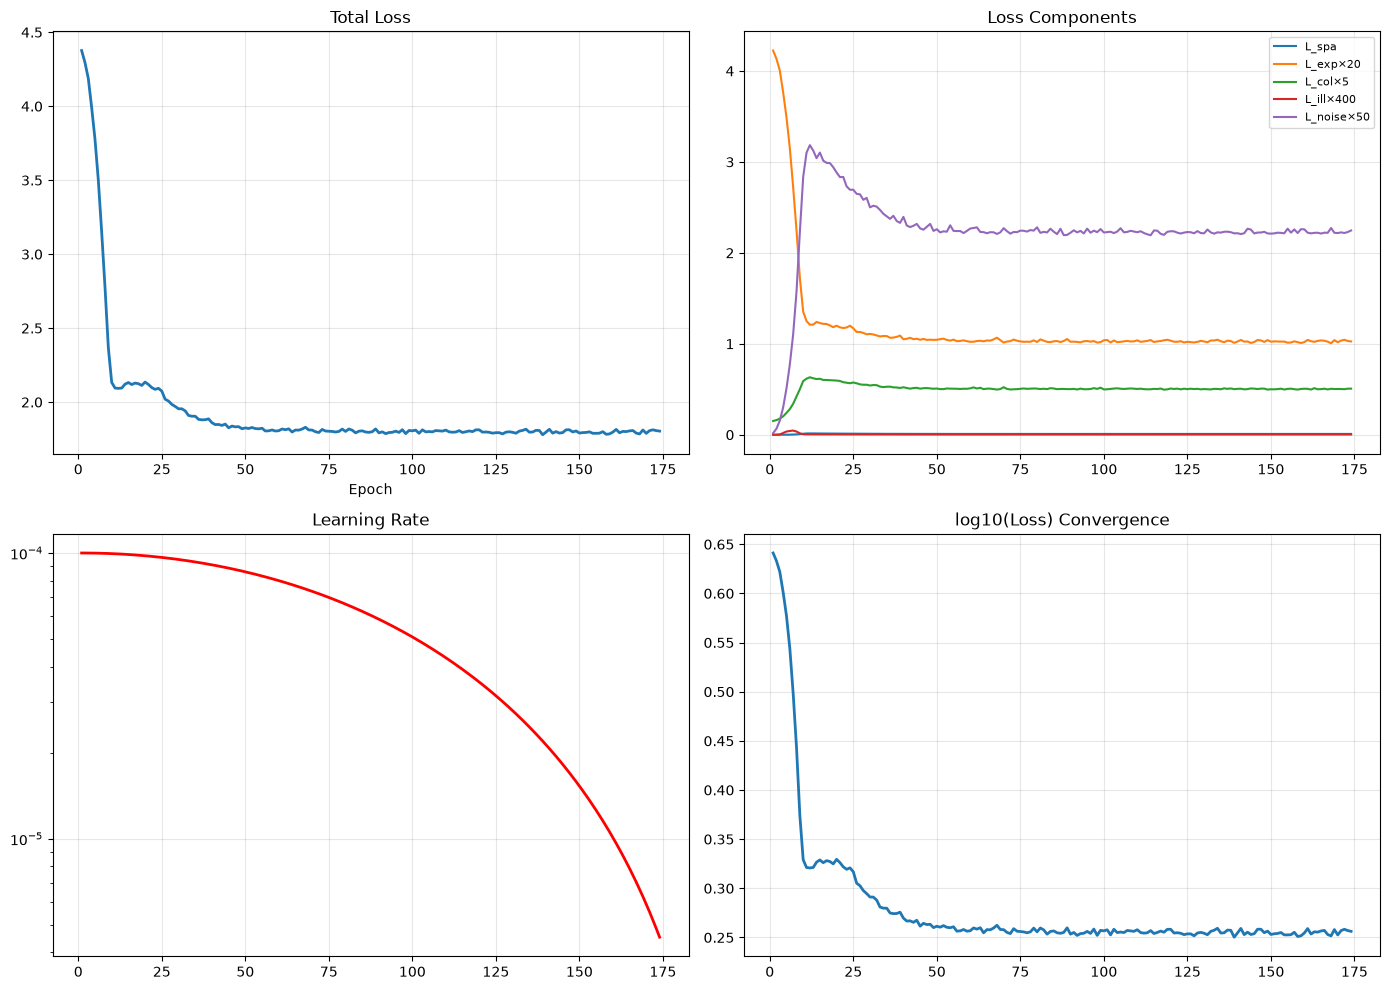

Saved: training_history_pp_seblock_v9.png


In [7]:
ep = range(1, len(history['loss'])+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'], linewidth=2)
axes[0,0].set_title('Total Loss'); axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, history['spa'],                    label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*20,       label='L_exp\u00d720')
axes[0,1].plot(ep, np.array(history['col'])*5,        label='L_col\u00d75')
axes[0,1].plot(ep, np.array(history['ill'])*400,      label='L_ill\u00d7400')
axes[0,1].plot(ep, np.array(history['noise'])*50,     label='L_noise\u00d750')
axes[0,1].set_title('Loss Components')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_pp_seblock_v9.png', dpi=150)
plt.show()
print('Saved: training_history_pp_seblock_v9.png')

### 8. Inference — trained denoiser + optional bilateral filter

The denoiser is now trained, not just applied at inference. `denoise=True`
still runs an additional bilateral filter pass on top for real-world photos
if you want extra smoothing; set it `False` to evaluate the model's own
learned denoising alone (e.g. for PSNR/SSIM against LOL-v2's Normal set).

In [8]:
def enhance_single_image(image_path, checkpoint=CHECKPOINT,
                          se_positions=(3,), reduction=4,
                          se_activation='relu', se_gate='sigmoid',
                          denoise=True, d=9, sigma_color=75, sigma_space=75):
    ckpt = torch.load(checkpoint, map_location=device)

    m = DCENetLite(use_attention=True, se_positions=se_positions, reduction=reduction,
                   se_activation=se_activation, se_gate=se_gate).to(device)
    m.load_state_dict(ckpt['model'])
    m.eval()

    dn = DenoiseHead().to(device)
    dn.load_state_dict(ckpt['denoise_head'])
    dn.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enh = dn(enhance_image_with_curve(inp, m(inp)))

    enh_np = (enh.squeeze(0).cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    if denoise:
        bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        bgr    = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.array(img)); axes[0].set_title('Input (low-light)');  axes[0].axis('off')
    axes[1].imshow(enh_np);        axes[1].set_title('Enhanced (Zero-DCE++ + DenoiseHead)' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_pp.png', dpi=150)
    plt.show()
    return enh_np

print('Usage:')
print('  enhance_single_image(\"your_photo.jpg\", denoise=True)   # real-world photos, extra smoothing on top')
print('  enhance_single_image(\"lolv2_test.jpg\", denoise=False)  # metric evaluation, learned denoiser only')
print('  # match se_positions/reduction/se_activation/se_gate to whatever CHECKPOINT was trained with')

Usage:
  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos, extra smoothing on top
  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation, learned denoiser only
  # match se_positions/reduction/se_activation/se_gate to whatever CHECKPOINT was trained with


---
### Version History

| Version | Key issue | Status |
|---|---|---|
| v1 (original) | `tanh*0.15`, wrong loss weights, broken pairing | Fixed in v2 |
| v2 | Working baseline | Good |
| v3 | `L_tv_enh` weight=500 \u2192 mode collapse to black | **Broken** |
| v4 | `L_tv_enh` removed, exposure upgraded to per-patch MSE, collapse guard added | Good (standard convs, 24-ch curve = original Zero-DCE architecture) |
| v5 | Added `DPEDColorLoss` + `VGGContentLoss` (LOL-v2 GT), single optimizer | Improved metrics, green-cast bias persisted |
| v6 | Added `ChannelBalanceLoss` \u2014 direct per-channel mean matching | Targeted fix for the cast |
| v7 | Hybrid losses removed entirely. Architecture rebuilt with depth-separable convs + single shared 3-channel curve, matching genuine Zero-DCE++. SE-Block fixed after Conv3. | Good (baseline before v8) |
| v8 | SE-Block placement/activation made configurable. Added trained `DenoiseHead` + `NoiseSuppressionLoss`. | **Broken** \u2014 noise loss's global minimum was a flat/black image; collapsed to `mean_brightness=0.09` by epoch 10 |
| **v9 (this notebook)** | `NoiseSuppressionLoss` rewritten to penalize only the *increase* in local variation over input (can't be minimized by flattening), threshold-based dark weighting, `w_noise` lowered to 5.0 with a 20-epoch warm-up ramp. Added `MAX_EXPOSURE` hard ceiling in `enhance_image_with_curve` (smoothly damps only brightening as pixels approach the ceiling) and an adaptive `ExposureControlLoss` target (holds back on already-bright input instead of always demanding e=0.52) \u2014 together addressing Zero-DCE's known tendency to overexpose already well-lit input. | **Current** |

**Reminder:** BAB II \u00a72.2.2 and Rumus 2.1 still describe the 24-channel/per-iteration-curve
architecture from v1\u2013v6 (which was actually original Zero-DCE). Update that section to
describe the single shared 3-channel curve. If keeping the DenoiseHead, MAX_EXPOSURE ceiling,
and/or adaptive exposure target, add a methodology paragraph for each, since they're now real
trained/architectural components, not post-processing -- and the exposure ceiling + adaptive
target pairing is arguably your strongest, most demonstrable novelty claim of the four v8/v9
additions (provable hard guarantee at inference + learned behavior during training).
